# Tutorial to GW data
Using GWUtils, we are able to fetch public GW databases and retrieve their characteristics and sky map

## 1) GW event 

### Load data

Events data are mainly stored in two online databases : GWTC, containing human-validated transients ; and GraceDB, storing data related to all alerts sent by the LVK network (started around O3)

GWTC identifies events via a tag starting with GW, e.g. "GW170817"
GraceDB stores events under a 'Superevent' structure, owning several alerts regarding the same event. Those are identified with a superevent id, e.g. "S250830bp".

Network unavailable (<Response [401]>); falling back to cached event for GW170817
{'$defs': {'CBCClassification': {'properties': {'astro': {'anyOf': [{'type': 'number'}, {'type': 'null'}], 'default': None, 'title': 'Astro'}, 'Terrestrial': {'anyOf': [{'type': 'number'}, {'type': 'null'}], 'default': None, 'title': 'Terrestrial'}, 'BBH': {'anyOf': [{'type': 'number'}, {'type': 'null'}], 'default': None, 'title': 'Bbh'}, 'BNS': {'anyOf': [{'type': 'number'}, {'type': 'null'}], 'default': None, 'title': 'Bns'}, 'NSBH': {'anyOf': [{'type': 'number'}, {'type': 'null'}], 'default': None, 'title': 'Nsbh'}, 'source_pipeline': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'default': None, 'title': 'Source Pipeline'}}, 'title': 'CBCClassification', 'type': 'object'}, 'Detector': {'enum': ['H1', 'L1', 'V1', 'K1'], 'title': 'Detector', 'type': 'string'}, 'UncertainQuantity': {'description': 'A measured value with asymmetric uncertainties.', 'properties': {'value': {'title': 'Value', 'type': 'n

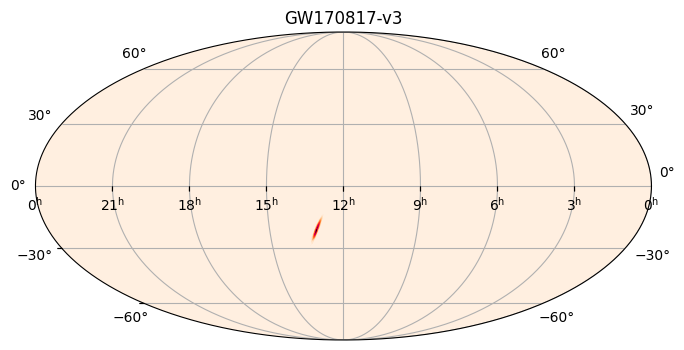

(<Figure size 900x400 with 1 Axes>,
 <AstroHoursMollweideAxes: title={'center': 'GW170817-v3'}>)

In [9]:
from GWUtils.models_gw import GWEvent

name = 'GW170817'
gw170817 = GWEvent(name, offline=False)  # Turn this flag to True at first run if no cache yet ; you may need ligo token to access non-public events

# Demonstration 
print(gw170817.model_json_schema())
gw170817.plot_event()

In [10]:
gw170817.to_dict()

{'superevent_id': 'G298048',
 'gw_id': 'GW170817-v3',
 'catalog': 'GWTC-1-confident',
 'created': None,
 't_start': None,
 't_end': None,
 't_0': datetime.datetime(2017, 8, 17, 12, 41, 4, 400000, tzinfo=TzInfo(0)),
 'gps': 1187008882.4,
 'detectors': '',
 'group': None,
 'preferred_event': None,
 'network_snr': 33.0,
 'far': 1e-07,
 'p_astro': 1.0,
 'skymap_ready': False,
 'pastro_ready': False,
 'classification': None,
 'mass_1': 1.46,
 'mass_1_lower': -0.1,
 'mass_1_upper': 0.12,
 'mass_2': 1.27,
 'mass_2_lower': -0.09,
 'mass_2_upper': 0.09,
 'chirp_mass': 1.186,
 'chirp_mass_lower': -0.001,
 'chirp_mass_upper': 0.001,
 'total_mass': None,
 'total_mass_lower': None,
 'total_mass_upper': None,
 'final_mass': 2.8,
 'final_mass_lower': None,
 'final_mass_upper': None,
 'luminosity_distance': 40.0,
 'luminosity_distance_lower': -15.0,
 'luminosity_distance_upper': 7.0,
 'redshift': 0.01,
 'redshift_lower': 0.0,
 'redshift_upper': 0.0,
 'chi_eff': 0.0,
 'chi_eff_lower': -0.01,
 'chi_eff_

## Compute regions of interest (MOCs)

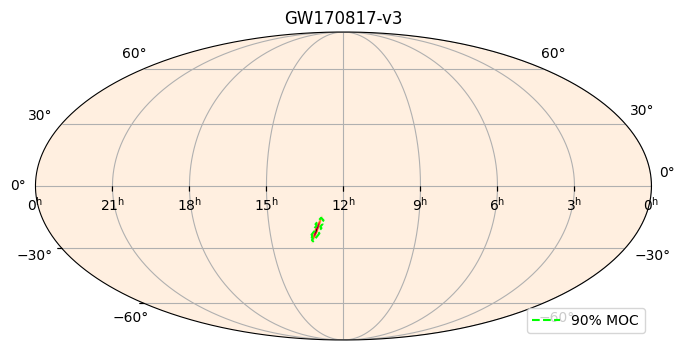

(<Figure size 900x400 with 1 Axes>,
 <AstroHoursMollweideAxes: title={'center': 'GW170817-v3'}>)

In [11]:
gw170817.plot_event(n_vertices=50)

### Extract MOC 

In [12]:
moc = gw170817.get_roi(n_vertices=50, format='moc')
moc_dict = gw170817.get_roi(n_vertices=50, format='dict')

In [13]:
type(moc)

mocpy.moc.moc.MOC

In [14]:
moc_dict

{'superevent_id': 'G298048',
 'percentile': 90,
 'order': 6,
 'area_deg2': 30.214571227602008,
 'n_vertices': 36,
 'contours': [[(198.98437499999997, -23.96948231775968),
   (199.68749999999997, -24.624318352164074),
   (198.98437499999997, -25.282603043311997),
   (199.68749999999997, -25.94447977237001),
   (198.98437499999997, -26.610097810733915),
   (198.28124999999997, -25.94447977237001),
   (197.57812499999997, -25.282603043311997),
   (196.87499999999997, -24.624318352164074),
   (196.17187499999997, -23.96948231775968),
   (195.46874999999997, -23.31795706533424),
   (194.76562499999997, -22.669609871750385),
   (195.46875, -22.024312837042164),
   (194.76562499999997, -21.381942579838892),
   (194.06249999999997, -20.742379954487138),
   (193.35937499999997, -20.105509787916006),
   (194.06249999999997, -19.47122063449069),
   (193.35937499999997, -18.839404547275457),
   (192.65624999999997, -18.20995686428301),
   (193.35937499999997, -17.58277600842541),
   (192.656249999

In [15]:
moc

5/6224 6227 6233 6235 11002 
6/24900 24902 24904-24905 24907 24929 24931 24946 24952 24954 25029 25031 25040 
 25042 44002 44014 

In [ ]:
from pathlib import Path
savePath = Path("/path/to/your/installation/of/LSST-GW/src/output") # TODO : adapt this path to your installation
moc.save(savePath / f"{name}_moc.fits", overwrite=True)

Now you can use the saved file to create a watchmap on a Rubin broker. 

## 2) Rubin past data (/!\ exercise)

At this point, two actions can be taken : 
- Configure a Rubin broker to acquire live alerts related to the localisation region of the event of our choice.
- Browse a broker alert database to see past (in particular, recent) alerts within this zone.

Live alerts configuration are mainly done on the broker website and are the topic of another tutorial under `Lasair tutorial.pdf`.
For now, let us look at what Rubin has already acquired for us.

If you have configured your watchmap and filter before, you now know how lasair works. Use the broker to fetch past alerts in the MOC. The watchmap will not help at first since it does not retrieve past alerts automatically. Instead, you can e.g. configure a filter manually that queries the watchmap region using the SQL wizard on the Lasair website. 